<a href="https://colab.research.google.com/github/Patricia-oliv/Processamento-de-Linguagem-Natural-NLP-/blob/main/C%C3%B3pia_de_Entra21_Aula_6_ABSA_OpenAI_GPT_5_6_Luna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Aula 6, Parte 2 — Análise de Sentimento por Aspectos (ABSA) com GPT-5.6 Luna

Nesta aula, vamos avançar da **análise de sentimento global** para a **análise de sentimento por aspectos** (*Aspect-Based Sentiment Analysis — ABSA*).

Em vez de atribuir apenas um sentimento ao comentário completo, queremos identificar:

- **o que está sendo avaliado**;
- **qual categoria de aspecto está envolvida**;
- **qual é a polaridade associada a esse aspecto**;
- **qual trecho do comentário sustenta a classificação**.

Usaremos três categorias de aspectos:

1. **Produtos**
2. **Embalagem**
3. **Entrega**

Para realizar a extração, usaremos a API da OpenAI com o modelo **GPT-5.6 Luna** e **Structured Outputs**.

### 1. Da análise global para a ABSA

Considere o comentário:

> *"O Veggie Burger estava ótimo, mas a entrega demorou muito."*

Uma análise global poderia classificar o texto como **misto**. A ABSA procura decompor essa avaliação:

| Categoria | Alvo | Polaridade |
|---|---|---|
| Produtos | Veggie Burger | positivo |
| Entrega | entrega | negativo |

A pergunta deixa de ser apenas **"qual é o sentimento do comentário?"** e passa a ser:

> **"Qual sentimento está associado a cada elemento da experiência descrita pelo cliente?"**

### 2. Estrutura dos aspectos

Neste notebook, adotaremos uma taxonomia pequena e previamente definida:

- **Produtos:** alimentos e bebidas comprados pelo cliente. Inclui sabor, temperatura, qualidade, quantidade, aparência, ingredientes, preparo e itens específicos do cardápio.
- **Embalagem:** acondicionamento físico do pedido, como recipiente, fechamento, vazamento, organização e proteção.
- **Entrega:** processo de entrega, incluindo rapidez, demora, chegada do pedido, entregador e problemas diretamente relacionados ao transporte.

Dentro de **Produtos**, tentaremos preservar também o **alvo específico**, como `Veggie Burger`, `batata` ou `refrigerante`.

Uma categoria que não aparece no comentário simplesmente **não será incluída**. Ausência de menção não significa sentimento neutro.

### 3. Preparação do ambiente

Instalaremos o SDK oficial da OpenAI e as bibliotecas usadas para organizar os dados.

O modelo GPT-5.6 Luna suporta o endpoint **Responses** e **Structured Outputs**. A saída estruturada será definida com classes do Pydantic, que funcionarão como um "molde" para a resposta do modelo.

In [ ]:
!pip install -q -U openai pydantic pandas tqdm matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.6/472.6 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 101.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is th

### 4. Upload da base de dados

Execute a célula abaixo e selecione o mesmo arquivo CSV de avaliações utilizado nas aulas anteriores.

O arquivo usa ponto e vírgula (`;`) como separador.

In [ ]:
import pandas as pd
from google.colab import files

arquivos_enviados = files.upload()

nome_arquivo = next(iter(arquivos_enviados))
df = pd.read_csv(nome_arquivo, sep=";")

print("Quantidade de avaliações:", len(df))
print("Colunas:", list(df.columns))

df.head()

Saving lanches_entra21_revisado.csv to lanches_entra21_revisado.csv
Quantidade de avaliações: 200
Colunas: ['username', 'data_hora', 'pedido', 'comentario', 'estrelas']


,username,data_hora,pedido,comentario,estrelas
0,burger_online79,01/08/2026 02:45,X-Bacon + Coca-Cola + molho barbecue,O pedido demorou demais e o X-Bacon chegou fri...,1
1,delivery_furb60,01/08/2026 04:50,X-Frango + onion rings,muito bom! o x-frango estava no ponto. a onion...,4
2,fome_garcia11,01/08/2026 05:16,X-Bacon + onion rings + água + maionese verde,Chegou e estava tudo em ordem. A embalagem não...,2
3,rapidinho_itoupava66,01/08/2026 11:50,X-Frango + batata grande,"Pedido recebido, sem grandes problemas.",3
4,blumenau_itoupava85,01/08/2026 12:00,X-Salada + batata grande + suco de laranja,"Boa comida, mas houve problema na entrega! Esq...",2


### 5. Preparação mínima dos comentários

Para modelos de linguagem, queremos preservar o máximo possível do texto original.

Por isso, **não removeremos pontuação, stopwords ou acentos**. Faremos apenas uma limpeza mínima:

- preencher valores ausentes;
- converter o comentário para texto;
- remover espaços extras no início e no final.

O comentário original continuará preservado.

In [ ]:
df["comentario_original"] = df["comentario"]

df["comentario_analise"] = (
    df["comentario"]
    .fillna("")
    .astype(str)
    .str.strip()
)

df = df[df["comentario_analise"] != ""].copy()

print("Comentários válidos para análise:", len(df))

df[["comentario_original", "comentario_analise"]].head()

Comentários válidos para análise: 200


,comentario_original,comentario_analise
0,O pedido demorou demais e o X-Bacon chegou fri...,O pedido demorou demais e o X-Bacon chegou fri...
1,muito bom! o x-frango estava no ponto. a onion...,muito bom! o x-frango estava no ponto. a onion...
2,Chegou e estava tudo em ordem. A embalagem não...,Chegou e estava tudo em ordem. A embalagem não...
3,"Pedido recebido, sem grandes problemas.","Pedido recebido, sem grandes problemas."
4,"Boa comida, mas houve problema na entrega! Esq...","Boa comida, mas houve problema na entrega! Esq..."


## Parte 1 — Conectando à API da OpenAI

### 6. Informando a chave da API

Como este notebook será compartilhado, **a chave não ficará gravada no código**.

A célula abaixo solicitará a chave manualmente em cada sessão. `getpass()` oculta o texto digitado na tela.

A chave ficará apenas na memória da sessão atual do Colab. Ao reiniciar o ambiente, será necessário informá-la novamente.

> Nunca escreva uma chave de API diretamente em uma célula que será compartilhada.

In [ ]:
from getpass import getpass
from openai import OpenAI

api_key = getpass("Digite sua chave da API da OpenAI: ")

client = OpenAI(api_key=api_key)

print("Cliente configurado para esta sessão.")

## Parte 2 — Definindo a saída estruturada

### 7. Criando o formato esperado

Queremos que o modelo devolva sempre a mesma estrutura.

Cada aspecto identificado deverá conter:

- `categoria`: Produtos, Embalagem ou Entrega;
- `alvo`: o elemento específico avaliado;
- `polaridade`: positivo, neutro, negativo ou misto;
- `evidencia`: pequeno trecho do comentário que sustenta a classificação.

Também guardaremos um `sentimento_geral` para permitir comparação com a análise por aspectos.

O Pydantic ajuda a garantir que a resposta siga essa estrutura.

In [ ]:
from typing import Literal
from pydantic import BaseModel


class Aspecto(BaseModel):
    categoria: Literal["Produtos", "Embalagem", "Entrega"]
    alvo: str
    polaridade: Literal["positivo", "neutro", "negativo", "misto"]
    evidencia: str


class AnaliseABSA(BaseModel):
    sentimento_geral: Literal["positivo", "neutro", "negativo", "misto"]
    aspectos: list[Aspecto]

### 8. Instruções para o modelo

Além do formato da saída, precisamos explicar **como interpretar os aspectos**.

Algumas regras são especialmente importantes:

- não inventar aspectos que não estejam sustentados pelo comentário;
- permitir mais de um produto no mesmo comentário;
- não usar `neutro` simplesmente porque uma categoria não foi mencionada;
- copiar em `evidencia` apenas um trecho curto realmente presente no comentário;
- quando uma mesma frase avaliar aspectos diferentes, separar as avaliações sempre que possível.

Exemplo:

> *"A batata estava ótima, mas a entrega demorou."*

deve produzir dois aspectos: **Produtos / batata / positivo** e **Entrega / entrega / negativo**.

In [ ]:
INSTRUCOES_ABSA = '''
Você realiza análise de sentimento baseada em aspectos (ABSA) em avaliações
de clientes de uma lanchonete.

Analise apenas as informações presentes no comentário.

CATEGORIAS PERMITIDAS

1. Produtos
Alimentos e bebidas comprados pelo cliente. Inclui itens específicos do
cardápio e avaliações de sabor, temperatura, qualidade, quantidade,
aparência, ingredientes e preparo.

2. Embalagem
Acondicionamento físico do pedido: embalagem, recipiente, fechamento,
vazamento, organização, proteção e problemas semelhantes.

3. Entrega
Processo de entrega: rapidez, demora, chegada do pedido, entregador,
localização e problemas diretamente relacionados ao transporte.

REGRAS

- Identifique somente aspectos realmente mencionados ou claramente avaliados.
- Não crie um aspecto para uma categoria que não aparece no comentário.
- A ausência de uma categoria NÃO significa sentimento neutro.
- Um comentário pode conter zero, um ou vários aspectos.
- Um comentário pode mencionar vários produtos. Registre cada produto
  separadamente quando houver avaliações distintas.
- Para Produtos, use como alvo o nome ou descrição do produto avaliado
  (por exemplo: "Veggie Burger", "batata", "refrigerante").
- Para Embalagem e Entrega, use um alvo curto e claro, como "embalagem"
  ou "entrega", salvo quando o texto indicar um alvo mais específico.
- A polaridade deve ser: positivo, neutro, negativo ou misto.
- Use "misto" somente quando o mesmo alvo receber avaliações positivas
  e negativas que não façam sentido separar.
- A evidência deve ser um trecho curto copiado do próprio comentário.
- Não invente evidências.
- Se o comentário apenas avaliar uma característica do alimento, como
  "o hambúrguer estava frio", classifique como Produtos.
- Se o texto atribuir explicitamente um problema à entrega, a categoria
  Entrega também pode ser registrada.
- O sentimento_geral resume o comentário como um todo.
'''

## Parte 3 — Fazendo uma primeira análise

### 9. Criando a função de ABSA

A função abaixo envia **um comentário** para o GPT-5.6 Luna.

Usaremos `client.responses.parse()`. Em vez de pedir ao modelo que escreva JSON livremente, informamos a classe `AnaliseABSA` em `text_format`.

Assim, o resultado retorna como um objeto Python já organizado segundo o esquema definido.

In [ ]:
MODELO = "gpt-5.6-luna"


def analisar_comentario(texto):
    resposta = client.responses.parse(
        model=MODELO,
        reasoning={"effort": "low"},
        input=[
            {
                "role": "system",
                "content": INSTRUCOES_ABSA
            },
            {
                "role": "user",
                "content": f"Comentário:\n{texto}"
            }
        ],
        text_format=AnaliseABSA
    )

    if resposta.output_parsed is None:
        raise ValueError("A API não retornou uma saída estruturada.")

    return resposta.output_parsed

### 10. Testando com um comentário da base

Antes de processar toda a base, vamos analisar apenas um comentário.

Isso é importante para verificar:

1. se a conexão com a API está funcionando;
2. se o esquema estruturado está adequado;
3. se a interpretação produzida pelo modelo faz sentido.

Você pode trocar o índice abaixo para testar outros comentários.

In [ ]:
comentario_id_teste = df.index[2]
comentario_teste = df.loc[comentario_id_teste, "comentario_analise"]

print("Comentário:")
print(comentario_teste)

resultado_teste = analisar_comentario(comentario_teste)

print("\nSentimento geral:", resultado_teste.sentimento_geral)
print("\nAspectos encontrados:")

if resultado_teste.aspectos:
    for aspecto in resultado_teste.aspectos:
        print(
            f"- {aspecto.categoria} | "
            f"{aspecto.alvo} | "
            f"{aspecto.polaridade} | "
            f'Evidência: "{aspecto.evidencia}"'
        )
else:
    print("Nenhum dos três aspectos foi identificado.")

Comentário:
Chegou e estava tudo em ordem. A embalagem não segurou bem o calor.

Sentimento geral: misto

Aspectos encontrados:
- Entrega | entrega | positivo | Evidência: "Chegou e estava tudo em ordem"
- Embalagem | embalagem | negativo | Evidência: "não segurou bem o calor"


### 11. Observando a estrutura diretamente

O resultado retornado não é apenas um texto: ele possui campos estruturados.

Podemos convertê-lo para um dicionário Python e visualizar sua organização.

In [ ]:
resultado_teste.model_dump()

{'sentimento_geral': 'misto',
 'aspectos': [{'categoria': 'Entrega',
   'alvo': 'entrega',
   'polaridade': 'positivo',
   'evidencia': 'Chegou e estava tudo em ordem'},
  {'categoria': 'Embalagem',
   'alvo': 'embalagem',
   'polaridade': 'negativo',
   'evidencia': 'não segurou bem o calor'}]}

## Parte 4 — Aplicando ABSA à base

### 12. Escolhendo quantos comentários processar

Cada comentário enviado representa uma chamada à API e, portanto, possui custo.

Para analisar **toda a base**, mantenha:

```python
LIMITE_COMENTARIOS = None
```

Para testes, é possível usar um número menor, como `20`.

O processamento abaixo fará uma chamada por comentário. Essa não é necessariamente a estratégia mais eficiente para grandes volumes, mas torna o funcionamento mais fácil de compreender.

In [ ]:
# None = processar todos os comentários.
# Para um teste rápido, use por exemplo: LIMITE_COMENTARIOS = 20
LIMITE_COMENTARIOS = 20

if LIMITE_COMENTARIOS is None:
    df_processamento = df.copy()
else:
    df_processamento = df.head(LIMITE_COMENTARIOS).copy()

print("Comentários que serão processados:", len(df_processamento))

Comentários que serão processados: 20


### 13. Processando os comentários

Para cada comentário, guardaremos:

- o índice original;
- o sentimento geral atribuído pelo GPT;
- a lista de aspectos encontrados.

Usaremos uma barra de progresso para acompanhar o processamento.

Se uma chamada específica falhar, o erro será registrado e o restante da base continuará sendo analisado.

In [ ]:
from tqdm.auto import tqdm

resultados_absa = []
erros_absa = []

for comentario_id, linha in tqdm(
    df_processamento.iterrows(),
    total=len(df_processamento),
    desc="Analisando comentários"
):
    texto = linha["comentario_analise"]

    try:
        analise = analisar_comentario(texto)

        resultados_absa.append({
            "comentario_id": comentario_id,
            "sentimento_geral_gpt": analise.sentimento_geral,
            "aspectos": [
                aspecto.model_dump()
                for aspecto in analise.aspectos
            ]
        })

    except Exception as erro:
        erros_absa.append({
            "comentario_id": comentario_id,
            "erro": str(erro)
        })

print("Análises concluídas:", len(resultados_absa))
print("Erros:", len(erros_absa))

Analisando comentários:   0%|          | 0/20 [00:00<?, ?it/s]

Análises concluídas: 20
Erros: 0


### 14. Resultados por comentário

Primeiro, vamos criar uma tabela em que cada linha ainda corresponde a um comentário.

A coluna `aspectos` contém uma lista, pois um único comentário pode avaliar vários elementos.

In [ ]:
df_resultados = pd.DataFrame(resultados_absa)

df_resultados.head()

,comentario_id,sentimento_geral_gpt,aspectos
0,0,negativo,"[{'categoria': 'Entrega', 'alvo': 'entrega', '..."
1,1,positivo,"[{'categoria': 'Produtos', 'alvo': 'x-frango',..."
2,2,misto,"[{'categoria': 'Entrega', 'alvo': 'entrega', '..."
3,3,neutro,"[{'categoria': 'Entrega', 'alvo': 'entrega', '..."
4,4,misto,"[{'categoria': 'Produtos', 'alvo': 'batata gra..."


## Parte 5 — Transformando aspectos em dados tabulares

### 15. Uma linha para cada aspecto

Para analisar os resultados com Pandas, é conveniente transformar a lista de aspectos em uma tabela.

Assim, um comentário como:

> *"O Veggie Burger estava ótimo, mas a entrega demorou."*

gera **duas linhas**:

| categoria | alvo | polaridade |
|---|---|---|
| Produtos | Veggie Burger | positivo |
| Entrega | entrega | negativo |

Essa transformação é importante: **uma linha da base original pode gerar várias observações analíticas**.

In [ ]:
linhas_aspectos = []

for resultado in resultados_absa:
    for aspecto in resultado["aspectos"]:
        linhas_aspectos.append({
            "comentario_id": resultado["comentario_id"],
            "sentimento_geral_gpt": resultado["sentimento_geral_gpt"],
            "categoria": aspecto["categoria"],
            "alvo": aspecto["alvo"],
            "polaridade": aspecto["polaridade"],
            "evidencia": aspecto["evidencia"]
        })

colunas_aspectos = [
    "comentario_id",
    "sentimento_geral_gpt",
    "categoria",
    "alvo",
    "polaridade",
    "evidencia"
]

df_aspectos = pd.DataFrame(
    linhas_aspectos,
    columns=colunas_aspectos
)

# Acrescenta o comentário original e as estrelas, quando disponíveis.
colunas_origem = ["comentario_analise"]

if "estrelas" in df.columns:
    colunas_origem.append("estrelas")

df_aspectos = df_aspectos.merge(
    df[colunas_origem],
    left_on="comentario_id",
    right_index=True,
    how="left"
)

print("Aspectos extraídos:", len(df_aspectos))

df_aspectos.head(15)

Aspectos extraídos: 42


,comentario_id,sentimento_geral_gpt,categoria,alvo,polaridade,evidencia,comentario_analise,estrelas
0,0,negativo,Entrega,entrega,negativo,O pedido demorou demais,O pedido demorou demais e o X-Bacon chegou fri...,1
1,0,negativo,Produtos,X-Bacon,negativo,o X-Bacon chegou frio,O pedido demorou demais e o X-Bacon chegou fri...,1
2,1,positivo,Produtos,x-frango,positivo,muito bom! o x-frango estava no ponto,muito bom! o x-frango estava no ponto. a onion...,4
3,1,positivo,Produtos,onion rings,positivo,a onion rings estava boa também,muito bom! o x-frango estava no ponto. a onion...,4
4,2,misto,Entrega,entrega,positivo,Chegou e estava tudo em ordem,Chegou e estava tudo em ordem. A embalagem não...,2
5,2,misto,Embalagem,embalagem,negativo,não segurou bem o calor,Chegou e estava tudo em ordem. A embalagem não...,2
6,3,neutro,Entrega,entrega,neutro,"Pedido recebido, sem grandes problemas.","Pedido recebido, sem grandes problemas.",3
7,4,misto,Produtos,batata grande,negativo,Esqueceram a batata grande,"Boa comida, mas houve problema na entrega! Esq...",2
8,4,misto,Entrega,entrega,negativo,Chegou bem depois do prazo informado,"Boa comida, mas houve problema na entrega! Esq...",2
9,5,positivo,Produtos,X-Salada,positivo,"Gostei do pedido inteiro, especialmente do X-S...","Gostei do pedido inteiro, especialmente do X-S...",4


### 16. Quantos aspectos aparecem em cada categoria?

Agora podemos contar quantas avaliações foram relacionadas a:

- Produtos;
- Embalagem;
- Entrega.

Essa contagem mede **menções avaliativas extraídas**, e não necessariamente o número de comentários.
Um mesmo comentário pode contribuir para mais de uma categoria.

In [ ]:
if len(df_aspectos) > 0:
    contagem_categorias = (
        df_aspectos["categoria"]
        .value_counts()
        .reindex(["Produtos", "Embalagem", "Entrega"], fill_value=0)
        .rename_axis("categoria")
        .reset_index(name="quantidade")
    )

    print(contagem_categorias)
else:
    print("Nenhum aspecto foi extraído.")

   categoria  quantidade
0   Produtos          29
1  Embalagem           5
2    Entrega           8


### 17. Polaridade por categoria

Uma das principais vantagens da ABSA é permitir comparar **sobre o que** os clientes são positivos ou negativos.

A tabela abaixo mostra a quantidade de polaridades em cada categoria.

In [ ]:
if len(df_aspectos) > 0:
    tabela_polaridades = pd.crosstab(
        df_aspectos["categoria"],
        df_aspectos["polaridade"]
    )

    ordem_polaridades = ["positivo", "neutro", "negativo", "misto"]

    tabela_polaridades = tabela_polaridades.reindex(
        columns=ordem_polaridades,
        fill_value=0
    )

    print(tabela_polaridades)
else:
    print("Nenhum aspecto foi extraído.")

polaridade  positivo  neutro  negativo  misto
categoria                                    
Embalagem          1       0         4      0
Entrega            3       1         4      0
Produtos          18       0        11      0


### 18. Percentuais de polaridade por categoria

As quantidades absolutas podem ser influenciadas pelo número de menções de cada aspecto.

Por isso, também podemos calcular a distribuição percentual dentro de cada categoria.

In [ ]:
if len(df_aspectos) > 0:
    tabela_percentuais = pd.crosstab(
        df_aspectos["categoria"],
        df_aspectos["polaridade"],
        normalize="index"
    ) * 100

    tabela_percentuais = (
        tabela_percentuais
        .reindex(
            columns=["positivo", "neutro", "negativo", "misto"],
            fill_value=0
        )
        .round(1)
    )

    print(tabela_percentuais)
else:
    print("Nenhum aspecto foi extraído.")

polaridade  positivo  neutro  negativo  misto
categoria                                    
Embalagem       20.0     0.0      80.0      0
Entrega         37.5    12.5      50.0      0
Produtos        62.1     0.0      37.9      0


### 19. Visualizando as categorias

O gráfico permite comparar rapidamente quantas avaliações foram identificadas para cada categoria.

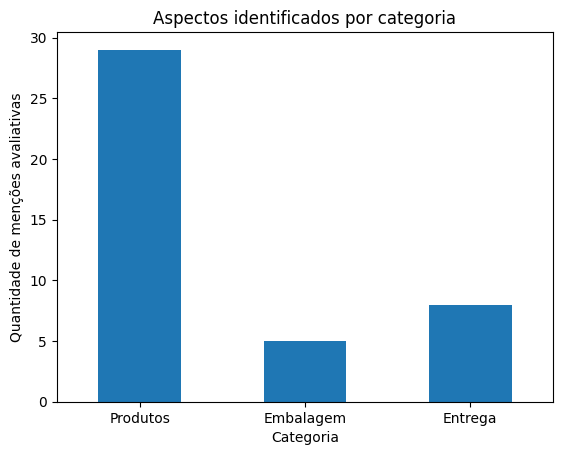

In [ ]:
if len(df_aspectos) > 0:
    ax = contagem_categorias.plot.bar(
        x="categoria",
        y="quantidade",
        legend=False,
        rot=0,
        title="Aspectos identificados por categoria"
    )

    ax.set_xlabel("Categoria")
    ax.set_ylabel("Quantidade de menções avaliativas")
else:
    print("Não há dados para gerar o gráfico.")

## Parte 6 — Investigando produtos específicos

### 20. Quais produtos aparecem mais?

Na categoria **Produtos**, o campo `alvo` preserva o item específico identificado pelo modelo.

Como pequenas diferenças de maiúsculas e minúsculas não deveriam criar produtos diferentes, criaremos também uma versão normalizada do alvo apenas para fins de agregação.

In [ ]:
if len(df_aspectos) > 0:
    df_aspectos["alvo_normalizado"] = (
        df_aspectos["alvo"]
        .astype(str)
        .str.strip()
        .str.casefold()
    )

    df_produtos = df_aspectos[
        df_aspectos["categoria"] == "Produtos"
    ].copy()

    produtos_mais_mencionados = (
        df_produtos["alvo_normalizado"]
        .value_counts()
        .head(15)
        .rename_axis("produto")
        .reset_index(name="quantidade")
    )

    print(produtos_mais_mencionados)
else:
    df_produtos = pd.DataFrame()
    print("Nenhum aspecto foi extraído.")

            produto  quantidade
0           x-bacon           3
1          x-frango           3
2   suco de laranja           3
3     batata grande           2
4          x-salada           2
5     veggie burger           2
6            pedido           2
7              água           2
8       onion rings           1
9    batata pequena           1
10      duplo bacon           1
11   coca-cola zero           1
12          guaraná           1
13           lanche           1
14           comida           1


### 21. Analisando um alvo específico

Podemos agora retomar a pergunta da aula anterior:

> **Como os clientes avaliam especificamente o Veggie Burger?**

Desta vez, porém, não estamos usando o sentimento da sentença inteira. O GPT identificou explicitamente o **alvo** e a **polaridade associada a ele**.

Você pode substituir `Veggie Burger` por outro produto.

In [ ]:
alvo_escolhido = "Veggie Burger"

if len(df_produtos) > 0:
    avaliacoes_alvo = df_produtos[
        df_produtos["alvo"].str.contains(
            alvo_escolhido,
            case=False,
            regex=False,
            na=False
        )
    ].copy()

    print(f'Alvo pesquisado: {alvo_escolhido}')
    print(f'Avaliações encontradas: {len(avaliacoes_alvo)}')


else:
    avaliacoes_alvo = pd.DataFrame()
    print("Não há produtos extraídos para pesquisar.")

avaliacoes_alvo[
        [
            "comentario_id",
            "alvo",
            "polaridade",
            "evidencia",
            "comentario_analise"
        ]
    ].head(20)

Alvo pesquisado: Veggie Burger
Avaliações encontradas: 2


,comentario_id,alvo,polaridade,evidencia,comentario_analise
17,9,Veggie Burger,negativo,chegou mal montado e já estava frio,O Veggie Burger chegou mal montado e já estava...
24,12,Veggie Burger,positivo,estava muito bom,Tudo chegou certinho e o Veggie Burger estava ...


### 22. Distribuição de sentimentos do alvo

Agora podemos resumir as polaridades associadas ao produto escolhido.

In [ ]:
if len(avaliacoes_alvo) > 0:
    resumo_alvo = (
        avaliacoes_alvo["polaridade"]
        .value_counts()
        .reindex(
            ["positivo", "neutro", "negativo", "misto"],
            fill_value=0
        )
        .rename_axis("polaridade")
        .reset_index(name="quantidade")
    )

    resumo_alvo["percentual"] = (
        resumo_alvo["quantidade"]
        / resumo_alvo["quantidade"].sum()
        * 100
    ).round(1)


else:
    print(f'Nenhuma avaliação encontrada para "{alvo_escolhido}".')

resumo_alvo

,polaridade,quantidade,percentual
0,positivo,1,50.0
1,neutro,0,0.0
2,negativo,1,50.0
3,misto,0,0.0


## Parte 7 — Inspeção e avaliação manual

### 23. O modelo acertou?

Uma saída estruturada é mais fácil de processar, mas isso **não significa que a interpretação seja sempre correta**.

Vamos selecionar algumas extrações para inspeção manual.

Para cada caso, verifique:

1. a categoria está correta?
2. o alvo foi identificado corretamente?
3. a polaridade faz sentido?
4. a evidência realmente sustenta a classificação?

Essa etapa é uma forma simples de introduzir a **avaliação de modelos de PLN**.

In [ ]:
if len(df_aspectos) > 0:
    amostra_avaliacao = df_aspectos.sample(
        n=min(10, len(df_aspectos)),
        random_state=42
    )

    amostra_avaliacao[
        [
            "comentario_analise",
            "categoria",
            "alvo",
            "polaridade",
            "evidencia"
        ]
    ]
else:
    print("Nenhum aspecto disponível para avaliação.")

amostra_avaliacao

,comentario_id,sentimento_geral_gpt,categoria,alvo,polaridade,evidencia,comentario_analise,estrelas,alvo_normalizado
25,12,positivo,Produtos,Guaraná,positivo,veio certinha,Tudo chegou certinho e o Veggie Burger estava ...,4,guaraná
13,7,negativo,Produtos,X-Frango,negativo,veio bem diferente do que eu esperava,O X-Frango veio bem diferente do que eu espera...,0,x-frango
8,4,misto,Entrega,entrega,negativo,Chegou bem depois do prazo informado,"Boa comida, mas houve problema na entrega! Esq...",2,entrega
26,13,positivo,Produtos,pedido,positivo,"bem preparado, saboroso","Pedido bem preparado, saboroso e entregue sem ...",3,pedido
4,2,misto,Entrega,entrega,positivo,Chegou e estava tudo em ordem,Chegou e estava tudo em ordem. A embalagem não...,2,entrega
39,19,misto,Produtos,sabor,positivo,Gostei do sabor,"Gostei do sabor, mas o conjunto ficou abaixo d...",2,sabor
19,10,negativo,Produtos,X-Salada,negativo,veio bem diferente do que eu esperava,O X-Salada veio bem diferente do que eu esperava.,1,x-salada
29,14,negativo,Entrega,entrega,negativo,Demorou muito para chegar,"Demorou muito para chegar; quando veio, o lanc...",1,entrega
30,14,negativo,Produtos,lanche,negativo,o lanche estava morno,"Demorou muito para chegar; quando veio, o lanc...",1,lanche
6,3,neutro,Entrega,entrega,neutro,"Pedido recebido, sem grandes problemas.","Pedido recebido, sem grandes problemas.",3,entrega


### 24. Comentários sem aspectos identificados

Também é informativo observar comentários em que nenhuma das três categorias foi extraída.

Isso pode ocorrer porque:

- o comentário não avalia Produtos, Embalagem ou Entrega;
- o texto é muito genérico;
- o modelo deixou de identificar um aspecto relevante.

Esses casos ajudam a discutir os limites da taxonomia escolhida.

In [ ]:
ids_com_aspectos = set(df_aspectos["comentario_id"]) if len(df_aspectos) > 0 else set()

comentarios_sem_aspectos = df_processamento[
    ~df_processamento.index.isin(ids_com_aspectos)
]

print("Comentários sem aspectos identificados:", len(comentarios_sem_aspectos))

comentarios_sem_aspectos[["comentario_analise"]].head(15)

Comentários sem aspectos identificados: 0


,comentario_analise


## Conclusão

Neste notebook, transformamos comentários livres em dados estruturados de ABSA.

O fluxo foi:

**comentário**
→ **GPT-5.6 Luna**
→ **Structured Outputs**
→ **categoria + alvo + polaridade + evidência**
→ **DataFrame**
→ **análise agregada**

A principal diferença em relação à análise de sentimento global é a **granularidade**.

Um único comentário pode conter, ao mesmo tempo:

- opinião positiva sobre um produto;
- opinião negativa sobre a entrega;
- opinião neutra ou negativa sobre a embalagem.

### Limitações importantes

A análise depende das categorias que definimos. Se um comentário avaliar, por exemplo, **preço** ou **atendimento**, essa informação não será registrada nesta versão.

Além disso, a saída estruturada garante o **formato** dos dados, mas não garante que toda interpretação do modelo esteja correta. Por isso, a inspeção e a avaliação manual continuam importantes.

### Possível próximo passo

Uma extensão natural seria acrescentar novas categorias, como **Preço** e **Atendimento**, e comparar como a mudança da taxonomia altera os resultados.

### Referências técnicas

- Modelo GPT-5.6 Luna: https://developers.openai.com/api/docs/models/gpt-5.6-luna
- Structured Outputs — Responses API: https://developers.openai.com/api/docs/guides/structured-outputs?api-mode=responses

A implementação deste notebook usa o padrão atual do SDK Python com `client.responses.parse()` e `text_format` definido por uma classe Pydantic.